# Variant functional consequences

This notebook generates two tables for:
- Protein-altering variants proportion (PAV) across Minor Allele Frequency bins for each study type
- Absolute rescaled effect size across Minor Allele Frequency bins

In both cases the effect of a credible set lead variant is chosen per trait (either disease set - `diseaseIds` or molecular trait - `geneId`) 
and study type (gwas-disease, gwas-measurement, eQTL, cis-pQTL).

### Variant duplication handling

Due to the fact that there are replicated signals in the lead variants and each lead variant may have
- multiple functional consequences (depending on the annotated transcript)
- effect size varying across studies/biosamples

we deduplicate the lead variants by choosing only the most severe functional consequence and largest absolute effect size respectively.

### Requirements:

- qualified, replicated lead variant effect (without maf filtering)

### Consequence scores 

Consequence scores are derived from [gentropy](https://github.com/opentargets/gentropy/blob/f1b7bb4f9482c4f7b50103ca5c0b7e59be352ce4/src/gentropy/config.py#L475) and are based on Sequence Ontology (SO) terms used by VEP. Higher scores indicate more severe consequences.

## Setup


In [19]:
from __future__ import annotations

from pathlib import Path

import plotnine as p9
from gentropy.common.session import Session
from great_tables import GT
from pyspark.sql import Window
from pyspark.sql import functions as f
from pyspark.sql import types as t

from manuscript_methods import OpenTargetsTheme, group_statistics
from manuscript_methods.datasets import LeadVariantEffect
from manuscript_methods.maf import prepare_maf_bins
from manuscript_methods.ve import SingleVariantEffectMethod, VariantEffect


In [20]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


In [21]:
session.spark


In [22]:
# Input paths and parameters
qualified_replicated_lve_path = "../../../data/intermediate_files/qualified_lead_variant_effect"
REM = 8
PAV_THRESHOLD = 0.66


# Output paths
ds_pav_path = "../../03-manuscript-figures/figure_2/data/figure_2_b.csv"
ds_abeta_path = "../../03-manuscript-figures/figure_2/data/figure_2_a.csv"


In [23]:
session.spark


## Prepare data for plotting

This section prepares datasets for plotting the functional consequences of lead variants.
This includes
- most severe consequence score from VEP transcript consequences assigned to transcript in the variant proximity
- `proteinAltering` variant (PAV) status based on consequence score filtering
- `absEstimatedBeta` from `rescaledStatistics`
- `geneId` for QTL variants and `diseaseIds` for GWAS variants (trait)


> [NOTE!] Due to the fact that lead variants - trait pairs are not unique (multiple signals can come from different cohorts/studies), we only keep the lead variants with the largest absolute effect size over disease/geneId to prevent double counting.

In [24]:
print("Number of qualified & replicated lead variant effects")
dataset = LeadVariantEffect.from_parquet(session, qualified_replicated_lve_path)
# Ensure that the order of diseases is consistent
disease_ids = f.concat_ws(",", f.sort_array(f.array_distinct(f.col("diseaseIds"))))
# Create partition column for window functions
partition = f.concat_ws(",", f.coalesce(f.col("geneId"), disease_ids), f.col("studyType"))
w1 = Window.partitionBy("variantId", "partition").orderBy(f.col("absEstimatedBeta").desc())
w2 = Window.partitionBy("variantId", "partition").orderBy(f.col("consequenceScore").desc())

effect_data = (
    dataset.df.select(
        f.col("variantId"),
        f.col("geneId"),
        f.col("diseaseIds").alias("diseaseIds"),
        VariantEffect(f.col("variantEffect"))
        .filter_effect_by_method(SingleVariantEffectMethod.VEP)
        .normalised_score.alias("vepScore"),
        f.col("majorLdPopulationMaf.value").alias("maf"),
        f.col("rescaledStatistics.directionOfEffect").alias("directionOfEffect"),
        f.col("rescaledStatistics.absEstimatedBeta").alias("absEstimatedBeta"),
        f.col("studyStatistics.studyType").alias("studyType"),
        f.col("leadVariantConsequence.mostSevereConsequence.transcriptConsequence.consequenceScore").alias(
            "consequenceScore"
        ),
        partition.alias("partition"),
    )
    # Since some variants are in deep intergenic regions, they do not have any transcript consequences
    # are more then 500kb away from any transcript. In such cases, we do not link it to the transcript
    # See https://www.ensembl.org/info/docs/tools/vep/script/vep_plugins.html#:~:text=VEP%20in%20pipelines.-,Intergenic%20variants,-When%20a%20variant
    # and https://github.com/opentargets/orchestration/blob/70bcfa4c4550e378a693ab2959048158c5f73135/src/orchestration/operators/batch/vep.py#L263
    .withColumn("consequenceScore", f.round(f.coalesce(f.col("consequenceScore"), f.col("vepScore")), 3))
    # All variants with score above >= PAV_THRESHOLD are considered protein altering variants
    # See https://github.com/opentargets/gentropy/blob/f1b7bb4f9482c4f7b50103ca5c0b7e59be352ce4/src/gentropy/config.py#L475
    # for exact SO term - consequenceScore mapping
    .withColumn("isProteinAltering", (f.col("consequenceScore") >= PAV_THRESHOLD).cast(t.ShortType()))
    # Since we have many variantId-diseaseId pairs with different effect sizes (due to multiple studies), to prevent double counting,
    # we only keep the one with the largest absolute beta
    .withColumn("hasLargestAbsBeta", f.row_number().over(w1) == 1)
    .withColumn("hasLargestVariantEffect", f.row_number().over(w2) == 1)
    .withColumn("largestAbsBetaDuplicationCount", f.count("*").over(w1))
    .withColumn("largestVariantEffectDuplicationCount", f.count("*").over(w2))
    # Determine if the variant with largest absolute beta is also the one with the largest variant effect
    .withColumn(
        "effectAligned",
        (f.col("hasLargestAbsBeta") & f.col("hasLargestVariantEffect")).cast(t.ShortType()),
    )
    .drop("vepScore")
    .dropDuplicates(["variantId", "partition"])
    .cache()
)

print(f"Before tranformations - {dataset.df.count():,}")
effect_data_count = effect_data.count()
print(f"After transformation - {effect_data_count:,}")


Number of qualified & replicated lead variant effects
Before tranformations - 459,516


After transformation - 121,490


In [25]:
GT(group_statistics(effect_data, "effectAligned").toPandas()).tab_header("Number of variants with aligned effects")


GT(_tbl_data=   effectAligned   count       %  percentage
0              1  121490  100.00       100.0, _body=<great_tables._gt_data.Body object at 0x785de38ce510>, _boxhead=Boxhead([ColInfo(var='effectAligned', type=<ColInfoTypeEnum.default: 1>, column_label='effectAligned', column_align='right', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='%', type=<ColInfoTypeEnum.default: 1>, column_label='%', column_align='right', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='percentage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x785de3d6a250>, _spanners=Spanners([]), _heading=Heading(title='Number of variants with aligned effects', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x785de301d610>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x785de301e1d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x785de301c250>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), headin

In [26]:
print("Number of variants per study type:")
GT(group_statistics(effect_data.select("variantId", "studyType"), "studyType").toPandas())


Number of variants per study type:


studyType,count,%,percentage
eqtl,83626,68.83,68.83364885998847
gwas-measurement,30708,25.28,25.27615441600132
gwas-disease,5886,4.84,4.844843196970944
cis-pqtl,1270,1.05,1.0453535270392624


In [27]:
GT(group_statistics(effect_data.filter(f.col("hasLargestAbsBeta")), "studyType").toPandas()).tab_header(
    "Number of variants after filtering for most severe study effect"
)


GT(_tbl_data=          studyType  count      %  percentage
0              eqtl  83626  68.83   68.833649
1  gwas-measurement  30708  25.28   25.276154
2      gwas-disease   5886   4.84    4.844843
3          cis-pqtl   1270   1.05    1.045354, _body=<great_tables._gt_data.Body object at 0x785d9adc0750>, _boxhead=Boxhead([ColInfo(var='studyType', type=<ColInfoTypeEnum.default: 1>, column_label='studyType', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='%', type=<ColInfoTypeEnum.default: 1>, column_label='%', column_align='right', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='percentage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x785e093a5a10>, _spanners=Spanners([]), _heading=Heading(title='Number of variants after filtering for most severe study effect', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x785d9adc0550>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x785de38ba850>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x785d9ada4b10>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=Tr

In [28]:
GT(group_statistics(effect_data.filter(f.col("hasLargestVariantEffect")), "studyType").toPandas()).tab_header(
    "Number of variants after filtering for most severe consequence"
)


GT(_tbl_data=          studyType  count      %  percentage
0              eqtl  83626  68.83   68.833649
1  gwas-measurement  30708  25.28   25.276154
2      gwas-disease   5886   4.84    4.844843
3          cis-pqtl   1270   1.05    1.045354, _body=<great_tables._gt_data.Body object at 0x785de38a3d10>, _boxhead=Boxhead([ColInfo(var='studyType', type=<ColInfoTypeEnum.default: 1>, column_label='studyType', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='%', type=<ColInfoTypeEnum.default: 1>, column_label='%', column_align='right', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='percentage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x785de3007e10>, _spanners=Spanners([]), _heading=Heading(title='Number of variants after filtering for most severe consequence', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x785de2fff610>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x785de2fff290>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x785de2ffeb50>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=Tru

In [29]:
effect_data.printSchema()


root
 |-- variantId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- diseaseIds: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- maf: double (nullable = true)
 |-- directionOfEffect: short (nullable = true)
 |-- absEstimatedBeta: double (nullable = true)
 |-- studyType: string (nullable = true)
 |-- consequenceScore: double (nullable = true)
 |-- partition: string (nullable = false)
 |-- isProteinAltering: short (nullable = true)
 |-- hasLargestAbsBeta: boolean (nullable = false)
 |-- hasLargestVariantEffect: boolean (nullable = false)
 |-- largestAbsBetaDuplicationCount: long (nullable = false)
 |-- largestVariantEffectDuplicationCount: long (nullable = false)
 |-- effectAligned: short (nullable = false)



In [30]:
GT(effect_data.groupBy("isProteinAltering").count().toPandas()).tab_header("Number of protein-altering variants")


GT(_tbl_data=   isProteinAltering   count
0                  1    6693
1                  0  114797, _body=<great_tables._gt_data.Body object at 0x785de2fe6d50>, _boxhead=Boxhead([ColInfo(var='isProteinAltering', type=<ColInfoTypeEnum.default: 1>, column_label='isProteinAltering', column_align='right', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x785de2f92c50>, _spanners=Spanners([]), _heading=Heading(title='Number of protein-altering variants', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x785de392e390>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x785de392e290>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x785de3902b10>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='center'), heading_title_font_size=OptionsInfo(scss=True, category='heading', type='px', value='125%'), heading_title_font_weight=OptionsInfo(scss=True, category='heading

### PAV proportion vs MAF bins dataset

To generate the PAV proportion we use the bucketing strategy defined by `maf_bins`. The splits decide the start and end of each maf bin.

Within each bin we sum the number of protein altering variants and use following formula to calculate the proportion:

$$ PAV=\frac{number\ of\ protein\ altering\ variants}{total\ number\ of\ variants} $$

since protein altering variants are encoded as 1 and non-protein altering as 0, we can simply use the average to calculate the proportion.


The standard error for the proportion is calculated as:
$$ SE(PAV) = \sqrt{\frac{PAV(1-PAV)}{total\ number\ of\ variants}} $$

We use the 0.95 confidence interval for upper and lower bounds:
$$ CI_{upper} = PAV + 1.96 * SE(PAV) $$
$$ CI_{lower} = PAV - 1.96 * SE(PAV) $$

In [31]:
splits = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

w_pve = Window.partitionBy("studyType").orderBy("mafBin.mafBinIndex")  # .rangeBetween(-1, 1)
# Since we are using the transcript-level annotations for protein-altering variants,
# we would like to see the maximum vep score effect per variant
pav_lve = effect_data.filter(f.col("hasLargestVariantEffect"))

pav_lve.groupBy("hasLargestVariantEffect").count().show()  # Sanity check

# Expressions for protein-altering variant statistics within each MAF bin
total_variants_in_bucket = f.count(f.lit(1)).over(w_pve)
altering_variants_in_bucket = f.sum(f.col("isProteinAltering")).over(w_pve)
nonaltering_variants_in_bucket = total_variants_in_bucket - altering_variants_in_bucket
pav_proportion = f.avg(f.col("isProteinAltering")).over(w_pve)  # We can do mean as isProteinAltering is 0/1
pav_stderr = f.sqrt(pav_proportion * (1 - pav_proportion) / total_variants_in_bucket)  # ([p * (1 - p) ]/ n)
pav_ci_lower = pav_proportion - 1.96 * pav_stderr
pav_ci_upper = pav_proportion + 1.96 * pav_stderr

# Retain the total amount of variants per study type across all bins
totals_overall = f.concat_ws(
    " ",
    f.col("studyType"),
    f.concat(f.lit("N=("), f.format_number(f.count(f.lit(1)).over(Window.partitionBy("studyType")), 0), f.lit(")")),
)

# Building the final dataset for PAV vs MAF bins
ds_pav = (
    prepare_maf_bins(pav_lve, splits=splits)
    .withColumn("totals_label", totals_overall)
    .withColumn(
        "PAV",
        f.struct(
            altering_variants_in_bucket.alias("nAlteringInBucket"),
            nonaltering_variants_in_bucket.alias("nNonAlteringInBucket"),
            total_variants_in_bucket.alias("nTotalInBucket"),
            pav_proportion.alias("alteringProportionInBucket"),
            pav_stderr.alias("alteringProportionInBucketStderr"),
            pav_ci_lower.alias("alteringProportionInBucketCILower"),
            pav_ci_upper.alias("alteringProportionInBucketCIUpper"),
        ),
    )
    .drop("absEstimatedBeta", "maf", "isProteinAltering")
    .dropDuplicates()
    .select("studyType", "PAV.*", "mafBin.*", "totals_label")
    .orderBy(f.asc("studyType"), f.asc("mafBinIndex"))
    .cache()
    .select(
        "nAlteringInBucket",
        "nNonAlteringInBucket",
        "nTotalInBucket",
        "alteringProportionInBucket",
        "alteringProportionInBucketStderr",
        "alteringProportionInBucketCILower",
        "alteringProportionInBucketCIUpper",
        "studyType",
        "mafBinRange",
        "mafBinLower",
        "mafBinUpper",
        "mafBinMidpoint",
        "mafBinIndex",
        "totals_label",
    )
)
print(f"Found {ds_pav.select('mafBinRange').distinct().count()} bins")
GT(ds_pav.toPandas()).tab_header("PAV vs MAF bins")


+-----------------------+------+
|hasLargestVariantEffect| count|
+-----------------------+------+
|                   true|121490|
+-----------------------+------+

Using following buckets [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
Found 7 bins


GT(_tbl_data=    nAlteringInBucket  nNonAlteringInBucket  nTotalInBucket  \
0                   7                     9              16   
1                  64                   178             242   
2                  97                   296             393   
3                 134                   491             625   
4                 165                   665             830   
5                 189                   854            1043   
6                 214                  1056            1270   
7                  32                   534             566   
8                 279                  7183            7462   
9                 545                 14506           15051   
10                908                 30147           31055   
11               1249                 46752           48001   
12               1602                 63881           65483   
13               1894                 81732           83626   
14                105                   319             424   
15                349                   862            1211   
16                486                  1281            1767   
17                591                  2152            2743   
18                679                  3043            3722   
19                750                  3979            4729   
20                802                  5084            5886   
21                802                  2279            3081   
22               1945                  5446            7391   
23               2457                  7955           10412   
24               2901                 12413           15314   
25               3155                 17116           20271   
26               3408                 21959           25367   
27               3783                 26925           30708   

    alteringProportionInBucket  alteringProportionInBucketStderr  \
0                     0.437500                          0.124020   
1                     0.264463                          0.028352   
2                     0.246819                          0.021749   
3                     0.214400                          0.016416   
4                     0.198795                          0.013853   
5                     0.181208                          0.011927   
6                     0.168504                          0.010503   
7                     0.056537                          0.009708   
8                     0.037389                          0.002196   
9                     0.036210                          0.001523   
10                    0.029238                          0.000956   
11                    0.026020                          0.000727   
12                    0.024464                          0.000604   
13                    0.022648                          0.000514   
14                    0.247642                          0.020962   
15                    0.288192                          0.013015   
16                    0.275042                          0.010623   
17                    0.215458                          0.007850   
18                    0.182429                          0.006330   
19                    0.158596                          0.005312   
20                    0.136256                          0.004472   
21                    0.260305                          0.007905   
22                    0.263158                          0.005122   
23                    0.235978                          0.004161   
24                    0.189435                          0.003166   
25                    0.155641                          0.002546   
26                    0.134348                          0.002141   
27                    0.123193                          0.001876   

    alteringProportionInBucketCILower  alteringProportionInBucketCIUpper  \
0                            0.194422                           0.680578   
1                            0.208


### Plot the PAV proportions across MAF bins ###





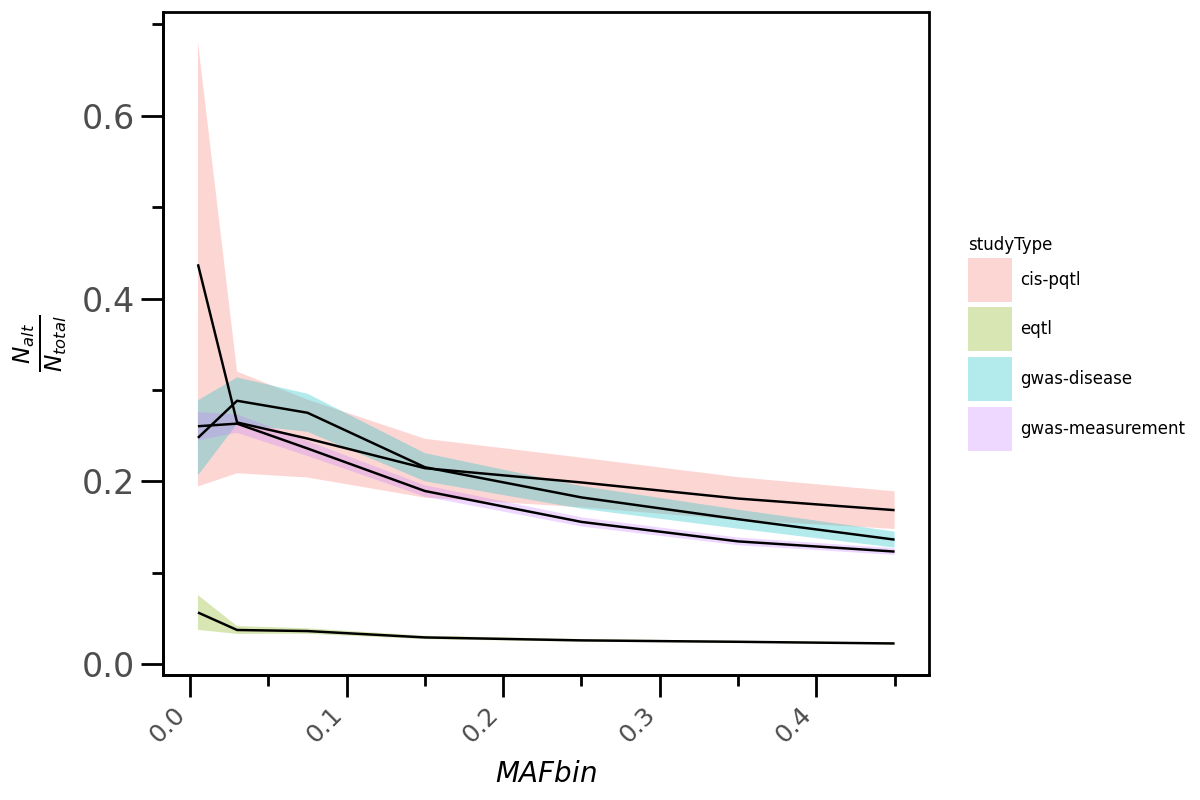

In [32]:
p2 = ds_pav.select(
    "alteringProportionInBucket",
    "mafBinMidpoint",
    "studyType",
    "alteringProportionInBucketCILower",
    "alteringProportionInBucketCIUpper",
).toPandas() >> p9.ggplot(
    mapping=p9.aes(
        x="mafBinMidpoint",
        y="alteringProportionInBucket",
        fill="studyType",
        ymin="alteringProportionInBucketCILower",
        ymax="alteringProportionInBucketCIUpper",
    ),
) + p9.geom_ribbon(alpha=0.3, color=None) + p9.labs(
    # title="Proportion of lead variant effects in replicated credible sets",
    x=r"$MAF bin$",
    y=r"$\frac{N_{alt}}{N_{total}}$",
) + p9.geom_line() + OpenTargetsTheme.categorical_theme(REM=6) + p9.theme(
    figure_size=(6, 4), legend_position="right"
) + p9.theme(axis_title_x=p9.element_text(size=10))
p2


### Abs beta vs MAF bins dataset

Similarly to the PAV proportion dataset, we use the same maf bins to calculate the average absolute rescaled effect size (`absEstimatedBeta`) within each bin.

The standard error for the mean is calculated as:
$$ SE(\overline{|\beta|}) = \frac{SD(\overline{|\beta|})}{\sqrt{total\ number\ of\ variants}} $$

In [33]:
splits = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
w_abeta = Window.partitionBy("studyType", "mafBin.mafBinIndex").orderBy()  # .rangeBetween(-1, 1)
# Since we are using the study-level effect,
# we would like to see the maximum abs beta per variant
# We also filter out variants with absEstimatedBeta >= 3 to avoid outliers
abeta_lve = effect_data.filter(f.col("hasLargestAbsBeta")).filter(f.col("absEstimatedBeta") < 3)

abeta_lve.groupBy("hasLargestAbsBeta").count().show()  # Sanity check

average_abs_beta = f.avg(f.col("absEstimatedBeta")).over(w_abeta)
min_abs_beta = f.min(f.col("absEstimatedBeta")).over(w_abeta)
max_abs_beta = f.max(f.col("absEstimatedBeta")).over(w_abeta)
std_abs_beta = f.std(f.col("absEstimatedBeta")).over(w_abeta)
total_abeta_variants_in_bucket = f.count(f.lit(1)).over(w_abeta)
abeta_stderr = std_abs_beta / f.sqrt(total_abeta_variants_in_bucket)
abeta_ci_lower = average_abs_beta - (f.lit(1.96) * abeta_stderr)
abeta_ci_upper = average_abs_beta + (f.lit(1.96) * abeta_stderr)


# Retain the total amount of variants per study type across all bins
totals_overall = f.concat_ws(
    " ",
    f.col("studyType"),
    f.concat(f.lit("N=("), f.format_number(f.count(f.lit(1)).over(Window.partitionBy("studyType")), 0), f.lit(")")),
)

ds_abeta = (
    prepare_maf_bins(abeta_lve, splits=splits)
    .withColumn("totals_label", totals_overall)
    .withColumn(
        "absBetaOverMafBin",
        f.struct(
            min_abs_beta.alias("minAbsEstimatedBetaInBucker"),
            max_abs_beta.alias("maxAbsEstimatedBetaInBucker"),
            std_abs_beta.alias("stdAbsEstimatedBetaInBucker"),
            total_abeta_variants_in_bucket.alias("nVariantsInBucket"),
            average_abs_beta.alias("avgAbsEstimatedBetaInBucket"),
            abeta_stderr.alias("avgAbsEstimatedBetaInBucketStderr"),
            abeta_ci_lower.alias("avgAbsEstimatedBetaInBucketCILower"),
            abeta_ci_upper.alias("avgAbsEstimatedBetaInBucketCIUpper"),
        ),
    )
    .drop("absEstimatedBeta", "maf", "isProteinAltering")
    .dropDuplicates()
    .select("studyType", "mafBin.*", "absBetaOverMafBin.*", "totals_label")
    .orderBy(f.asc("studyType"), f.asc("mafBinIndex"))
    .cache()
    .select(
        "minAbsEstimatedBetaInBucker",
        "maxAbsEstimatedBetaInBucker",
        "stdAbsEstimatedBetaInBucker",
        "nVariantsInBucket",
        "avgAbsEstimatedBetaInBucket",
        "avgAbsEstimatedBetaInBucketStderr",
        "avgAbsEstimatedBetaInBucketCILower",
        "avgAbsEstimatedBetaInBucketCIUpper",
        "studyType",
        "mafBinRange",
        "mafBinLower",
        "mafBinUpper",
        "mafBinMidpoint",
        "mafBinIndex",
        "totals_label",
    )
)
print(f"Found {ds_abeta.select('mafBinRange').distinct().count()} bins")
GT(ds_abeta.toPandas()).tab_header("Abs beta vs MAF bins")


+-----------------+------+
|hasLargestAbsBeta| count|
+-----------------+------+
|             true|121490|
+-----------------+------+

Using following buckets [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
Found 7 bins


GT(_tbl_data=    minAbsEstimatedBetaInBucker  maxAbsEstimatedBetaInBucker  \
0                      0.361968                     2.028047   
1                      0.110754                     1.489421   
2                      0.073253                     2.091797   
3                      0.073263                     1.504885   
4                      0.041626                     1.117937   
5                      0.042377                     1.007952   
6                      0.036633                     0.941019   
7                      1.042445                     2.998782   
8                      0.479681                     2.999794   
9                      0.334611                     2.997831   
10                     0.259188                     2.960271   
11                     0.209475                     2.252562   
12                     0.198555                     2.205570   
13                     0.190195                     2.186370   
14                     0.089575                     2.918998   
15                     0.055772                     2.790093   
16                     0.035953                     2.326832   
17                     0.021113                     1.723695   
18                     0.021024                     1.832911   
19                     0.016559                     1.575317   
20                     0.014400                     1.613348   
21                     0.034567                     2.999040   
22                     0.013479                     2.688338   
23                     0.009491                     2.997138   
24                     0.007113                     2.126742   
25                     0.006515                     2.626065   
26                     0.005598                     2.815239   
27                     0.004912                     2.096805   

    stdAbsEstimatedBetaInBucker  nVariantsInBucket  \
0                      0.526436                 16   
1                      0.386249                226   
2                      0.269561                151   
3                      0.264808                232   
4                      0.223829                205   
5                      0.192482                213   
6                      0.194649                227   
7                      0.416080                566   
8                      0.570309               6896   
9                      0.467188               7589   
10                     0.391289              16004   
11                     0.343820              16946   
12                     0.321840              17482   
13                     0.313732              18143   
14                     0.508462                424   
15                     0.350596                787   
16                     0.265271                556   
17                     0.194123                976   
18                     0.173640                979   
19                     0.137088               1007   
20                     0.122448               1157   
21                     0.427103               3081   
22                     0.189206               4310   
23                     0.170699               3021   
24                     0.122306               4902   
25                     0.115347               4957   
26                     0.142149               5096   
27                     0.083393               5341   

    avgAbsEstimatedBetaInBucket  avgAbsEstimatedBetaInBucketStderr  \
0                      1.015569                           0.131609   
1                      0.669968                           0.025693   
2                      0.435050                           0.021937   
3                      0.406907                           0.017385   
4                      0.332111                           0.015633   
5                      0.282504                           0.013189   
6                      0.268833                           0.012919   
7  

### Plot the abs beta across MAF bins ###

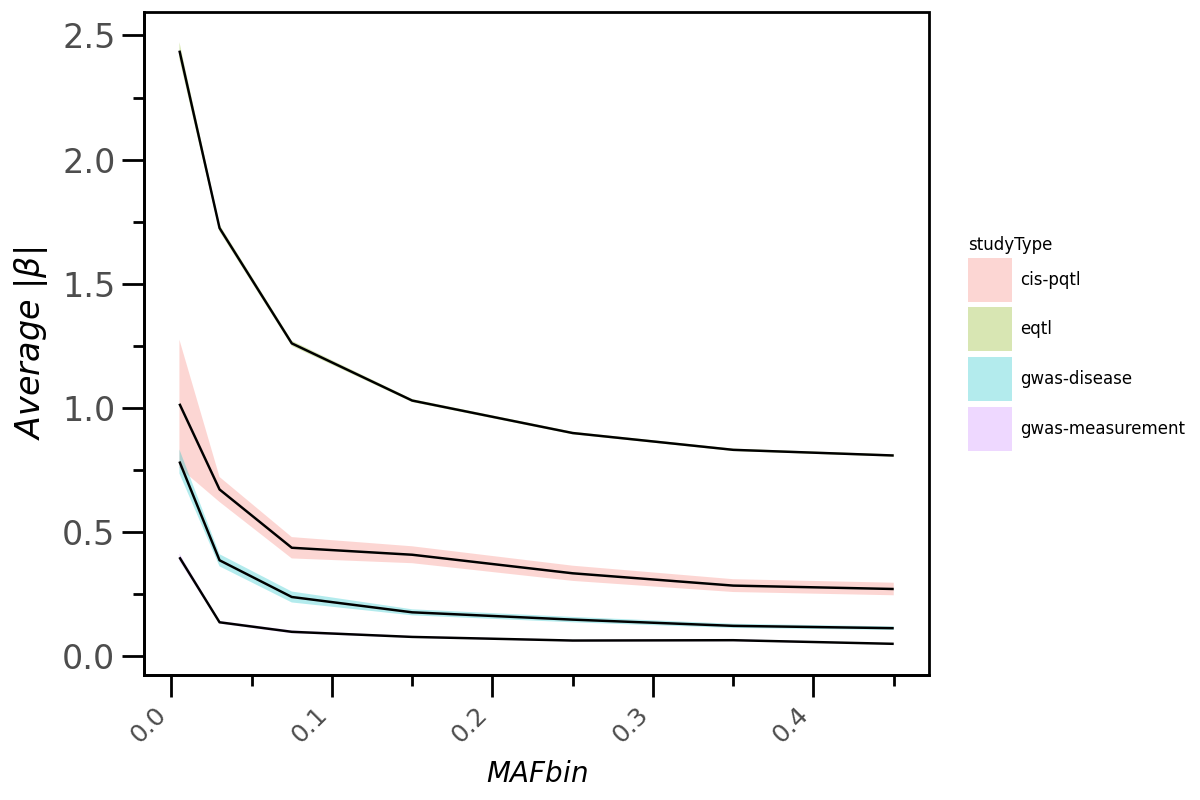

In [34]:
p3 = (
    ds_abeta.select(
        "avgAbsEstimatedBetaInBucket",
        "mafBinMidpoint",
        "studyType",
        "avgAbsEstimatedBetaInBucketCILower",
        "avgAbsEstimatedBetaInBucketCIUpper",
    ).toPandas()
    >> p9.ggplot(
        mapping=p9.aes(
            x="mafBinMidpoint",
            y="avgAbsEstimatedBetaInBucket",
            fill="studyType",
            ymin="avgAbsEstimatedBetaInBucketCILower",
            ymax="avgAbsEstimatedBetaInBucketCIUpper",
        ),
    )
    + p9.geom_ribbon(alpha=0.3, color=None)
    + p9.labs(  # title="Average absolute beta in MAF bins",
        x=r"$MAF bin$",
        y=r"$Average\ |\beta|$",
    )
    + OpenTargetsTheme.categorical_theme(REM=6)
    + p9.theme(figure_size=(6, 4), legend_position="right")
    + p9.theme(axis_title_x=p9.element_text(size=10))
    + p9.geom_line()
)
p3


### Save datasets for plotting 

In [35]:
## Save the dataset for plotting
Path(ds_abeta_path).parent.mkdir(parents=True, exist_ok=True)
Path(ds_pav_path).parent.mkdir(parents=True, exist_ok=True)
ds_abeta.toPandas().to_csv(ds_abeta_path, index=False)
ds_pav.toPandas().to_csv(ds_pav_path, index=False)


In [36]:
session.spark.stop()
